### Project Context and Exploration Goals

**Objective:**
To collect logo exposure data by zone, we need to perform frame-by-frame predictions. As observed in previous explorations, the target videos typically last between **9 and 10 minutes**. Consequently, running the model on every single frame (at **30 frames per second**) is computationally expensive and extremely time-consuming.

**Optimization Strategy:**
While code optimizations (such as GPU batch inference and parallel video downloading) and model selection (using lightweight models for faster inference) provide improvements, the **most significant efficiency gain** comes from reducing the **sampling rate** (the number of frames analyzed per second).

**The Trade-off:**
There is an inherent trade-off between **accuracy** (how close the calculated KPIs are to the "Ground Truth" obtained at 30 FPS) and **processing speed**. Lowering the frame rate drastically improves speed but introduces approximations.

**Methodology:**
Prior to this analysis, the inference pipeline was executed using **four** different frame rates to evaluate this trade-off:
*   **30 FPS:** Represents the **Ground Truth** (exact KPIs, no approximation, slow).
*   **10 FPS, 5 FPS & 3 FPS:** Represent **Approximations** (estimated KPIs, significantly faster).

The goal of this notebook is to quantify the error margin of these approximations to determine the best balance between speed and accuracy.

In [21]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the graphics style for a more professional rendering
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [22]:
# Loading the data
df_frame_3 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_3.csv")
df_frame_5 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_5.csv")
df_frame_10 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_10.csv")
df_frame_30 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_30.csv")

# Renaming columns to identify the frequency (frame rate)
df_frame_3.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f3",
    "average_box_area_pixels": "average_box_area_pixels_f3"
}, inplace=True)

df_frame_5.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f5",
    "average_box_area_pixels": "average_box_area_pixels_f5"
}, inplace=True)

df_frame_10.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f10",
    "average_box_area_pixels": "average_box_area_pixels_f10"
}, inplace=True)

df_frame_30.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f30",
    "average_box_area_pixels": "average_box_area_pixels_f30"
}, inplace=True)

# Merging the dataframes
# We merge on video_id and exposure_zone to compare the same elements
df_merge = pd.merge(df_frame_3.drop(columns=['game_id', 'video_url']), 
                    df_frame_5.drop(columns=['game_id', 'video_url']),  
                    on=['video_id', 'exposure_zone'], how='inner')

df_merge = pd.merge(df_merge, 
                    df_frame_10.drop(columns=['game_id', 'video_url']), 
                    on=['video_id', 'exposure_zone'], how='inner')

df_merge = pd.merge(df_merge, 
                    df_frame_30.drop(columns=['game_id', 'video_url']), 
                    on=['video_id', 'exposure_zone'], how='inner')

In [23]:
print(f"Number of videos in the analysis sample: {df_merge['video_id'].nunique()}")

Number of videos in the analysis sample: 30


The sample is small because running the code at 30 FPS is very time-consuming, but it should still be sufficient to provide useful insights.

In [24]:
# Global view
display(df_merge.describe())

# Detailed statistics by exposure zone for each sampling frequency
print("\n--- Statistics for 3 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f3', 'average_box_area_pixels_f3']].describe())

print("\n--- Statistics for 5 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f5', 'average_box_area_pixels_f5']].describe())

print("\n--- Statistics for 10 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f10', 'average_box_area_pixels_f10']].describe())

print("\n--- Statistics for 30 FPS (Ground Truth) ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f30', 'average_box_area_pixels_f30']].describe())

,exposure_time_seconds_f3,average_box_area_pixels_f3,exposure_time_seconds_f5,average_box_area_pixels_f5,exposure_time_seconds_f10,average_box_area_pixels_f10,exposure_time_seconds_f30,average_box_area_pixels_f30
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,376.924400,2513.519400,376.825333,2516.012267,376.748000,2518.796600,376.786733,2518.137733
std,155.557192,1636.817995,155.787452,1626.158846,155.947854,1628.413888,155.892808,1624.086944
min,0.330000,219.510000,0.400000,268.190000,0.300000,317.970000,0.570000,318.100000
25%,314.252500,1090.837500,313.900000,1091.047500,314.400000,1097.997500,314.872500,1092.925000
50%,439.500000,2254.230000,439.500000,2263.415000,440.350000,2277.275000,440.100000,2287.315000
75%,476.502500,3578.987500,477.750000,3560.457500,477.100000,3575.147500,477.100000,3546.510000
max,606.670000,8507.100000,608.000000,8407.880000,608.400000,8594.590000,608.500000,8426.360000



--- Statistics for 3 FPS ---


exposure_time_seconds_f3                                  \
                                       count        mean         std     min   
exposure_zone                                                                  
back-court-logo                         30.0  348.567000  181.653674    6.00   
basket-logo                             30.0  461.311000   36.131173  399.67   
mid-court-logo                          30.0  332.777667  150.643132   45.33   
side-court-led-logo                     30.0  400.022000  117.299808  145.33   
side-court-logo                         30.0  341.944333  203.812134    0.33   

                                                          \
                          25%      50%       75%     max   
exposure_zone                                              
back-court-logo      211.4200  440.500  471.2475  577.67   
basket-logo          442.6700  455.000  476.5025  577.67   
mid-court-logo       232.9175  360.330  465.4975  529.33   
side-court-led-logo  334.6700  425.500  477.7475  606.67   
side-court-logo      253.5800  442.665  486.0850  585.67   

                    average_box_area_pixels_f3                            \
                                         count         mean          std   
exposure_zone                                                              
back-court-logo                           30.0  3006.775333  1354.891990   
basket-logo                               30.0   511.758667   104.238994   
mid-court-logo                            30.0  3788.935333   947.479042   
side-court-led-logo                       30.0  3475.367333  1643.885775   
side-court-logo                           30.0  1784.760333   855.912266   

                                                                       
                         min        25%       50%        75%      max  
exposure_zone                                                          
back-court-logo      1242.00  1958.2475  2805.495  3611.5625  6276.12  
basket-logo           318.10   467.9400   496.965   543.3525   846.22  
mid-court-logo       1724.99  3138.7650  3768.660  4398.9650  5417.91  
side-court-led-logo  1809.13  2163.3175  3104.310  4230.8100  8507.10  
side-court-logo       219.51  1090.8375  2020.045  2246.3750  3790.06


--- Statistics for 5 FPS ---


exposure_time_seconds_f5                                 \
                                       count        mean         std    min   
exposure_zone                                                                 
back-court-logo                         30.0  347.906667  182.367849    6.2   
basket-logo                             30.0  461.113333   36.281911  399.0   
mid-court-logo                          30.0  332.853333  150.732976   44.2   
side-court-led-logo                     30.0  399.913333  117.496714  142.8   
side-court-logo                         30.0  342.340000  203.959341    0.4   

                                                  average_box_area_pixels_f5  \
                        25%    50%     75%    max                      count   
exposure_zone                                                                  
back-court-logo      209.05  440.7  471.10  576.0                       30.0   
basket-logo          442.25  455.2  477.75  578.4                       30.0   
mid-court-logo       233.30  359.5  466.95  530.0                       30.0   
side-court-led-logo  336.45  426.6  479.90  608.0                       30.0   
side-court-logo      258.20  441.2  487.70  584.4                       30.0   

                                                                             \
                            mean          std      min        25%       50%   
exposure_zone                                                                 
back-court-logo      3020.205333  1366.254267  1253.61  1948.9525  2808.615   
basket-logo           511.845667   104.478884   317.53   466.0925   496.635   
mid-court-logo       3787.443333   942.223073  1724.08  3194.2125  3787.980   
side-court-led-logo  3459.278333  1611.292568  1805.68  2232.2650  2998.660   
side-court-logo      1801.288667   828.111902   268.19  1091.0475  2025.640   

                                         
                           75%      max  
exposure_zone                            
back-court-logo      3600.5475  6283.59  
basket-logo           544.1550   848.93  
mid-court-logo       4392.9525  5451.49  
side-court-led-logo  4429.6450  8407.88  
side-court-logo      2246.2475  3777.56


--- Statistics for 10 FPS ---


exposure_time_seconds_f10                                 \
                                        count        mean         std    min   
exposure_zone                                                                  
back-court-logo                          30.0  348.193333  182.388970    6.1   
basket-logo                              30.0  461.080000   36.272935  399.8   
mid-court-logo                           30.0  332.416667  150.927053   44.0   
side-court-led-logo                      30.0  399.890000  117.826369  145.5   
side-court-logo                          30.0  342.160000  204.167517    0.3   

                                                      \
                         25%     50%      75%    max   
exposure_zone                                          
back-court-logo      209.950  441.70  471.000  576.3   
basket-logo          441.900  454.60  477.100  578.0   
mid-court-logo       230.475  360.00  466.525  530.1   
side-court-led-logo  336.425  426.45  480.300  608.4   
side-court-logo      255.200  440.40  487.775  585.3   

                    average_box_area_pixels_f10                            \
                                          count         mean          std   
exposure_zone                                                               
back-court-logo                            30.0  3005.366000  1360.875902   
basket-logo                                30.0   512.140667   104.476295   
mid-court-logo                             30.0  3791.988667   942.978073   
side-court-led-logo                        30.0  3476.829000  1626.730258   
side-court-logo                            30.0  1807.658667   816.136751   

                                                                       
                         min        25%       50%        75%      max  
exposure_zone                                                          
back-court-logo      1258.73  1927.8400  2808.625  3601.3675  6328.04  
basket-logo           317.97   469.8225   496.510   544.2825   849.16  
mid-court-logo       1722.17  3167.8200  3781.720  4393.1975  5443.81  
side-court-led-logo  1805.84  2243.9425  3013.010  4375.0450  8594.59  
side-court-logo       372.99  1097.9975  2023.045  2244.2200  3770.90


--- Statistics for 30 FPS (Ground Truth) ---


exposure_time_seconds_f30                                  \
                                        count        mean         std     min   
exposure_zone                                                                   
back-court-logo                          30.0  347.974000  182.581907    6.10   
basket-logo                              30.0  461.102667   36.310931  400.30   
mid-court-logo                           30.0  332.608333  150.642946   44.33   
side-court-led-logo                      30.0  400.035667  117.456154  145.63   
side-court-logo                          30.0  342.213000  204.189052    0.57   

                                                         \
                          25%     50%       75%     max   
exposure_zone                                             
back-court-logo      208.6350  440.98  470.8950  576.37   
basket-logo          442.1475  454.62  477.1000  578.07   
mid-court-logo       230.7425  359.18  466.4500  530.77   
side-court-led-logo  336.6750  426.75  479.3100  608.50   
side-court-logo      254.0750  442.90  487.9025  584.63   

                    average_box_area_pixels_f30                            \
                                          count         mean          std   
exposure_zone                                                               
back-court-logo                            30.0  3003.628000  1353.924893   
basket-logo                                30.0   512.148000   104.751183   
mid-court-logo                             30.0  3790.613333   943.085813   
side-court-led-logo                        30.0  3470.453667  1620.626636   
side-court-logo                            30.0  1813.845667   811.948236   

                                                                       
                         min        25%       50%        75%      max  
exposure_zone                                                          
back-court-logo      1263.09  1938.8250  2806.375  3606.2050  6309.93  
basket-logo           318.10   468.2850   496.595   544.6975   850.80  
mid-court-logo       1727.07  3217.7575  3784.885  4395.8475  5443.64  
side-court-led-logo  1808.35  2250.6225  3011.710  4383.1575  8426.36  
side-court-logo       329.44  1092.9250  2022.495  2247.9875  3773.12

Based on the statistical analysis across four sampling rates, the results demonstrate that frame rate reduction is an exceptionally effective optimization strategy with minimal impact on measurement accuracy. The most striking finding is the remarkable stability of exposure time measurements: all three approximation rates (10, 5, and 3 FPS) deviate by less than 0.5 seconds from the 30 FPS ground truth, representing an error margin well under 0.2%. The average box area metric shows slightly more sensitivity to sampling rate but remains highly reliable, with all approximations staying within 1% of ground truth values. Critically, the relative performance rankings across all five exposure zones remain completely consistent regardless of frame rate

In [25]:
# Calculation of differences compare to reality (30fps)
# If the result is positive, the approximation underestimates. If negative, it overestimates.

# Comparison 3 FPS vs 30 FPS
df_merge['exposure_time_diff_3_30'] = df_merge['exposure_time_seconds_f30'] - df_merge['exposure_time_seconds_f3']
df_merge['average_box_area_diff_3_30'] = df_merge['average_box_area_pixels_f30'] - df_merge['average_box_area_pixels_f3']

# Comparison 5 FPS vs 30 FPS
df_merge['exposure_time_diff_5_30'] = df_merge['exposure_time_seconds_f30'] - df_merge['exposure_time_seconds_f5']
df_merge['average_box_area_diff_5_30'] = df_merge['average_box_area_pixels_f30'] - df_merge['average_box_area_pixels_f5']

# Comparison 10 FPS vs 30 FPS
df_merge['exposure_time_diff_10_30'] = df_merge['exposure_time_seconds_f30'] - df_merge['exposure_time_seconds_f10']
df_merge['average_box_area_diff_10_30'] = df_merge['average_box_area_pixels_f30'] - df_merge['average_box_area_pixels_f10']

# Display of difference statistics
display(df_merge[['exposure_time_diff_3_30', 'average_box_area_diff_3_30', 
                  'exposure_time_diff_5_30', 'average_box_area_diff_5_30',
                  'exposure_time_diff_10_30', 'average_box_area_diff_10_30']].describe())

print("\n--- Detail of differences (3 FPS vs 30 FPS) by zone ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_diff_3_30', 'average_box_area_diff_3_30']].describe())

print("\n--- Detail of differences (5 FPS vs 30 FPS) by zone ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_diff_5_30', 'average_box_area_diff_5_30']].describe())

print("\n--- Detail of differences (10 FPS vs 30 FPS) by zone ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_diff_10_30', 'average_box_area_diff_10_30']].describe())

,exposure_time_diff_3_30,average_box_area_diff_3_30,exposure_time_diff_5_30,average_box_area_diff_5_30,exposure_time_diff_10_30,average_box_area_diff_10_30
count,150.000000,150.000000,150.00000,150.000000,150.000000,150.000000
mean,-0.137667,4.618333,-0.03860,2.125467,0.038733,-0.658867
std,1.738579,83.450728,1.03167,51.955232,1.297720,34.140396
min,-6.500000,-362.720000,-4.80000,-480.660000,-2.570000,-168.230000
25%,-1.022500,-7.960000,-0.63000,-2.227500,-0.392500,-1.920000
50%,-0.085000,-0.040000,-0.10000,0.715000,-0.030000,0.100000
75%,0.745000,4.252500,0.48250,5.682500,0.270000,2.877500
max,5.060000,705.120000,3.73000,182.670000,11.270000,243.010000



--- Detail of differences (3 FPS vs 30 FPS) by zone ---


exposure_time_diff_3_30                                    \
                                      count      mean       std   min     25%   
exposure_zone                                                                   
back-court-logo                        30.0 -0.593000  2.339537 -6.50 -1.4950   
basket-logo                            30.0 -0.208333  1.135542 -3.90 -0.7125   
mid-court-logo                         30.0 -0.169333  1.687969 -3.27 -0.9825   
side-court-led-logo                    30.0  0.013667  1.494564 -3.33 -1.0375   
side-court-logo                        30.0  0.268667  1.808087 -4.20 -0.6050   

                                         average_box_area_diff_3_30  \
                       50%     75%   max                      count   
exposure_zone                                                         
back-court-logo     -0.320  0.6250  5.06                       30.0   
basket-logo          0.115  0.3675  1.47                       30.0   
mid-court-logo      -0.285  0.5500  4.10                       30.0   
side-court-led-logo  0.150  0.9525  2.44                       30.0   
side-court-logo      0.220  0.9275  4.10                       30.0   

                                                                             \
                          mean         std     min      25%    50%      75%   
exposure_zone                                                                 
back-court-logo      -3.147333   28.324661  -84.12 -10.9150 -1.575   5.4825   
basket-logo           0.389333    1.194496   -1.44  -0.3375  0.100   1.1400   
mid-court-logo        1.678000   43.136509 -120.94 -10.5375 -3.315  11.0350   
side-court-led-logo  -4.913667  123.342875 -362.72 -32.7850 -5.835  33.5150   
side-court-logo      29.085333  130.765592  -47.09  -1.8925  1.115   4.0400   

                             
                        max  
exposure_zone                
back-court-logo       63.24  
basket-logo            4.58  
mid-court-logo       122.47  
side-court-led-logo  239.98  
side-court-logo      705.12


--- Detail of differences (5 FPS vs 30 FPS) by zone ---


exposure_time_diff_5_30                                    \
                                      count      mean       std   min     25%   
exposure_zone                                                                   
back-court-logo                        30.0  0.067333  0.848479 -1.97 -0.6200   
basket-logo                            30.0 -0.010667  0.731281 -1.33 -0.5925   
mid-court-logo                         30.0 -0.245000  1.013232 -2.90 -0.8600   
side-court-led-logo                    30.0  0.122333  0.895928 -1.67 -0.5025   
side-court-logo                        30.0 -0.127000  1.514314 -4.80 -0.5300   

                                         average_box_area_diff_5_30  \
                       50%     75%   max                      count   
exposure_zone                                                         
back-court-logo      0.120  0.7225  1.50                       30.0   
basket-logo         -0.215  0.3825  1.70                       30.0   
mid-court-logo      -0.350  0.3225  2.23                       30.0   
side-court-led-logo  0.130  0.4825  2.83                       30.0   
side-court-logo     -0.115  0.5200  3.73                       30.0   

                                                                          \
                          mean        std     min    25%    50%      75%   
exposure_zone                                                              
back-court-logo     -16.577333  88.355959 -480.66 -4.430  0.080   4.7825   
basket-logo           0.302333   1.078756   -2.83 -0.155  0.260   0.7550   
mid-court-logo        3.170000  21.968205  -51.16 -6.605  0.065   6.6250   
side-court-led-logo  11.175333  59.659817 -147.97 -6.415  9.810  30.7475   
side-court-logo      12.557000  38.151047  -20.81 -1.075  1.305   4.1175   

                             
                        max  
exposure_zone                
back-court-logo       26.34  
basket-logo            2.67  
mid-court-logo        56.59  
side-court-led-logo  175.51  
side-court-logo      182.67


--- Detail of differences (10 FPS vs 30 FPS) by zone ---


exposure_time_diff_10_30                            \
                                       count      mean       std   min   
exposure_zone                                                            
back-court-logo                         30.0 -0.219333  0.728257 -2.57   
basket-logo                             30.0  0.022667  0.422977 -0.73   
mid-court-logo                          30.0  0.191667  2.215893 -1.97   
side-court-led-logo                     30.0  0.145667  1.266278 -1.23   
side-court-logo                         30.0  0.053000  1.150814 -1.90   

                                                  average_box_area_diff_10_30  \
                        25%    50%     75%    max                       count   
exposure_zone                                                                   
back-court-logo     -0.4825 -0.070  0.1225   1.20                        30.0   
basket-logo         -0.2700  0.000  0.3525   0.90                        30.0   
mid-court-logo      -0.4000 -0.170  0.2225  11.27                        30.0   
side-court-led-logo -0.2700  0.070  0.3000   6.30                        30.0   
side-court-logo     -0.4975 -0.015  0.2700   4.97                        30.0   

                                                                          \
                         mean        std     min      25%    50%     75%   
exposure_zone                                                              
back-court-logo     -1.738000  18.596720  -78.56  -1.9200 -0.115  2.2475   
basket-logo          0.007333   0.726223   -2.14  -0.2275 -0.005  0.3225   
mid-court-logo      -1.375333  29.298868 -126.22  -2.3825  1.305  5.5225   
side-court-led-logo -6.375333  50.580363 -168.23 -16.9675  0.140  7.8300   
side-court-logo      6.187000  46.270479  -53.57  -1.3550  0.070  2.3325   

                             
                        max  
exposure_zone                
back-court-logo       37.10  
basket-logo            1.64  
mid-court-logo        50.50  
side-court-led-logo  125.69  
side-court-logo      243.01

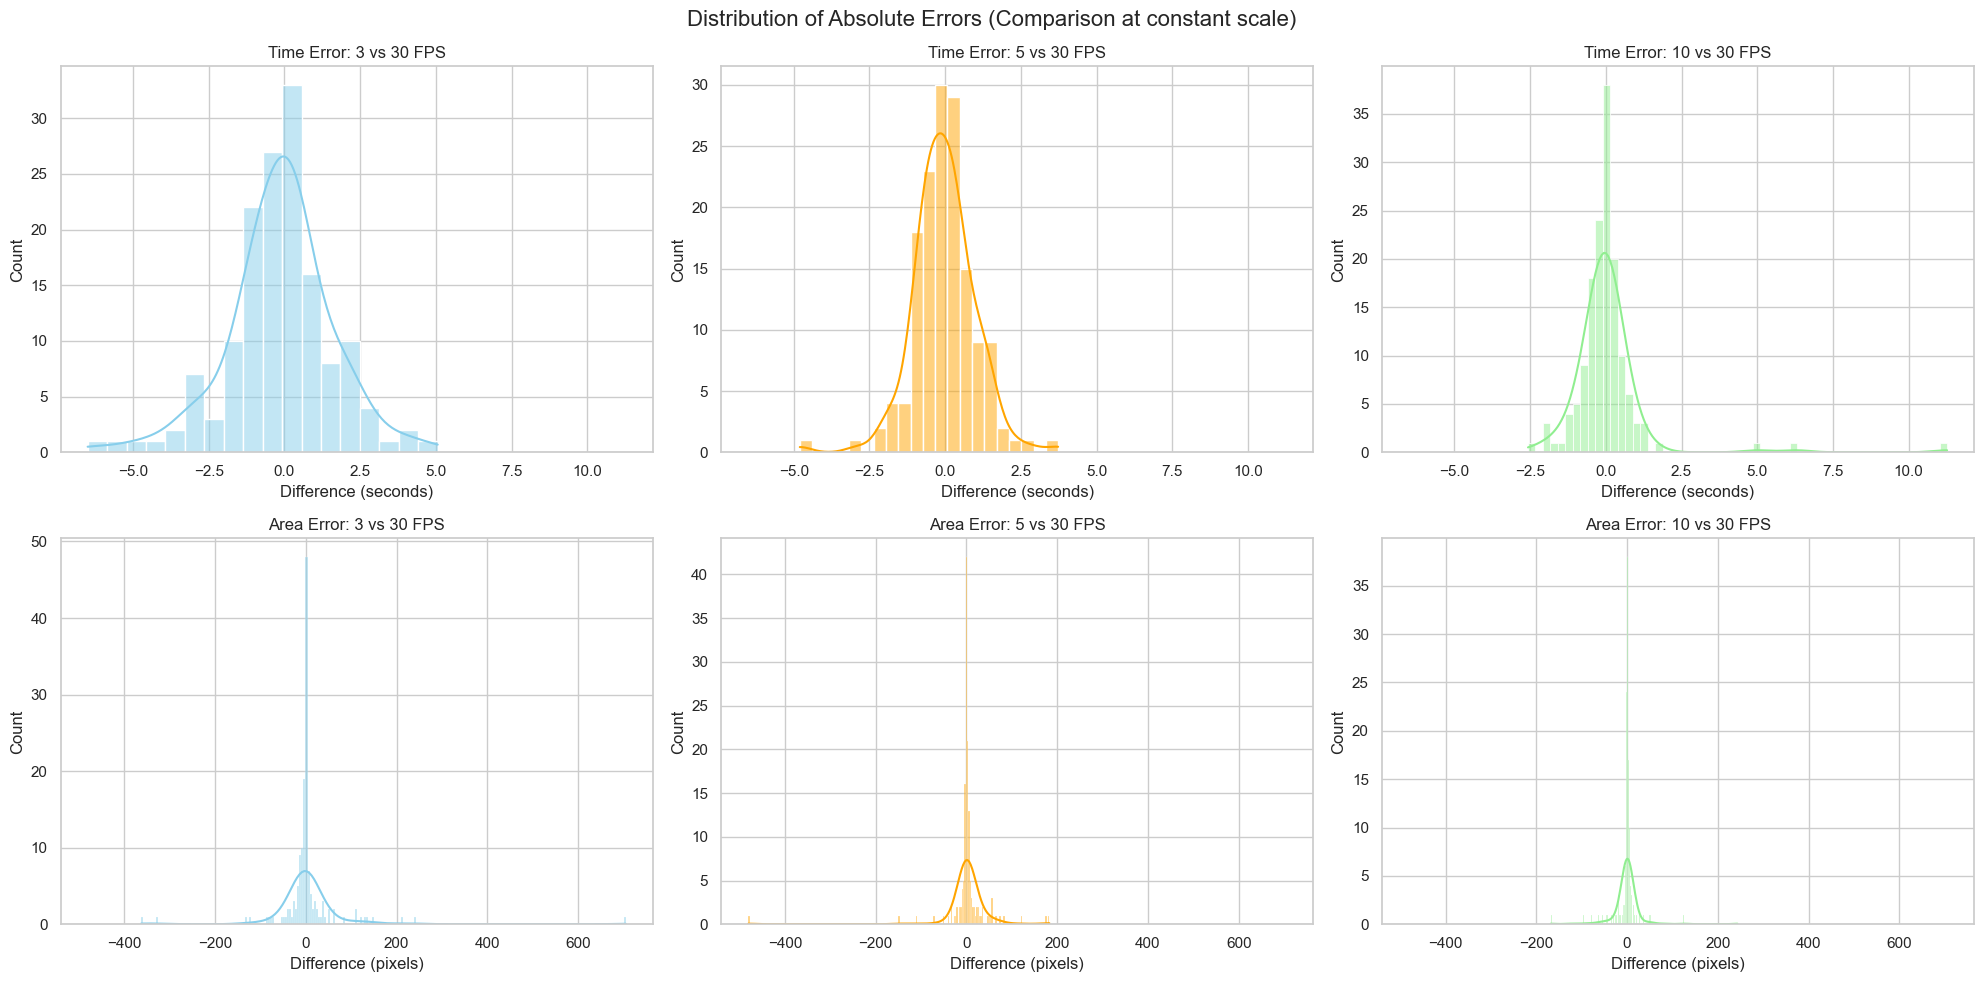

In [26]:
# 1. Definition of common limits for the X axis
# For time (Second): we include 3, 5 and 10 fps
time_min = min(df_merge["exposure_time_diff_5_30"].min(), 
               df_merge["exposure_time_diff_3_30"].min(), 
               df_merge["exposure_time_diff_10_30"].min())

time_max = max(df_merge["exposure_time_diff_5_30"].max(), 
               df_merge["exposure_time_diff_3_30"].max(), 
               df_merge["exposure_time_diff_10_30"].max())

# 5% margin
time_margin = (time_max - time_min) * 0.05
time_xlim = (time_min - time_margin, time_max + time_margin)

# For area (Pixels): we include 3, 5 and 10 fps
area_min = min(df_merge["average_box_area_diff_5_30"].min(), 
               df_merge["average_box_area_diff_3_30"].min(), 
               df_merge["average_box_area_diff_10_30"].min())

area_max = max(df_merge["average_box_area_diff_5_30"].max(), 
               df_merge["average_box_area_diff_3_30"].max(), 
               df_merge["average_box_area_diff_10_30"].max())

# 5% margin
area_margin = (area_max - area_min) * 0.05
area_xlim = (area_min - area_margin, area_max + area_margin)


# 2. Creation of graphs (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 10)) # I widened the figure a bit (20, 10)
fig.suptitle("Distribution of Absolute Errors (Comparison at constant scale)", fontsize=16)

# --- Row 1: Exposure time ---

# 5 FPS vs 30 FPS (Column 0)
sns.histplot(df_merge["exposure_time_diff_3_30"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Time Error: 3 vs 30 FPS")
axes[0, 0].set_xlabel("Difference (seconds)")
axes[0, 0].set_xlim(time_xlim)

# 3 FPS vs 30 FPS (Column 1)
sns.histplot(df_merge["exposure_time_diff_5_30"], kde=True, ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Time Error: 5 vs 30 FPS")
axes[0, 1].set_xlabel("Difference (seconds)")
axes[0, 1].set_xlim(time_xlim)

# 10 FPS vs 30 FPS (Column 2) - NEW
sns.histplot(df_merge["exposure_time_diff_10_30"], kde=True, ax=axes[0, 2], color="lightgreen")
axes[0, 2].set_title("Time Error: 10 vs 30 FPS")
axes[0, 2].set_xlabel("Difference (seconds)")
axes[0, 2].set_xlim(time_xlim)


# --- Row 2: Average Area ---

# 5 FPS vs 30 FPS (Column 0)
sns.histplot(df_merge["average_box_area_diff_3_30"], kde=True, ax=axes[1, 0], color="skyblue")
axes[1, 0].set_title("Area Error: 3 vs 30 FPS")
axes[1, 0].set_xlabel("Difference (pixels)")
axes[1, 0].set_xlim(area_xlim)

# 3 FPS vs 30 FPS (Column 1)
sns.histplot(df_merge["average_box_area_diff_5_30"], kde=True, ax=axes[1, 1], color="orange")
axes[1, 1].set_title("Area Error: 5 vs 30 FPS")
axes[1, 1].set_xlabel("Difference (pixels)")
axes[1, 1].set_xlim(area_xlim)

# 10 FPS vs 30 FPS (Column 2) - NEW
sns.histplot(df_merge["average_box_area_diff_10_30"], kde=True, ax=axes[1, 2], color="lightgreen")
axes[1, 2].set_title("Area Error: 10 vs 30 FPS")
axes[1, 2].set_xlabel("Difference (pixels)")
axes[1, 2].set_xlim(area_xlim)

plt.tight_layout()
plt.show()

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\2211686479.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_3_30', ax=axes[0, 0], palette="Oranges")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\2211686479.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_5_30', ax=axes[0, 1], palette="Blues")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\2211686479.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_me

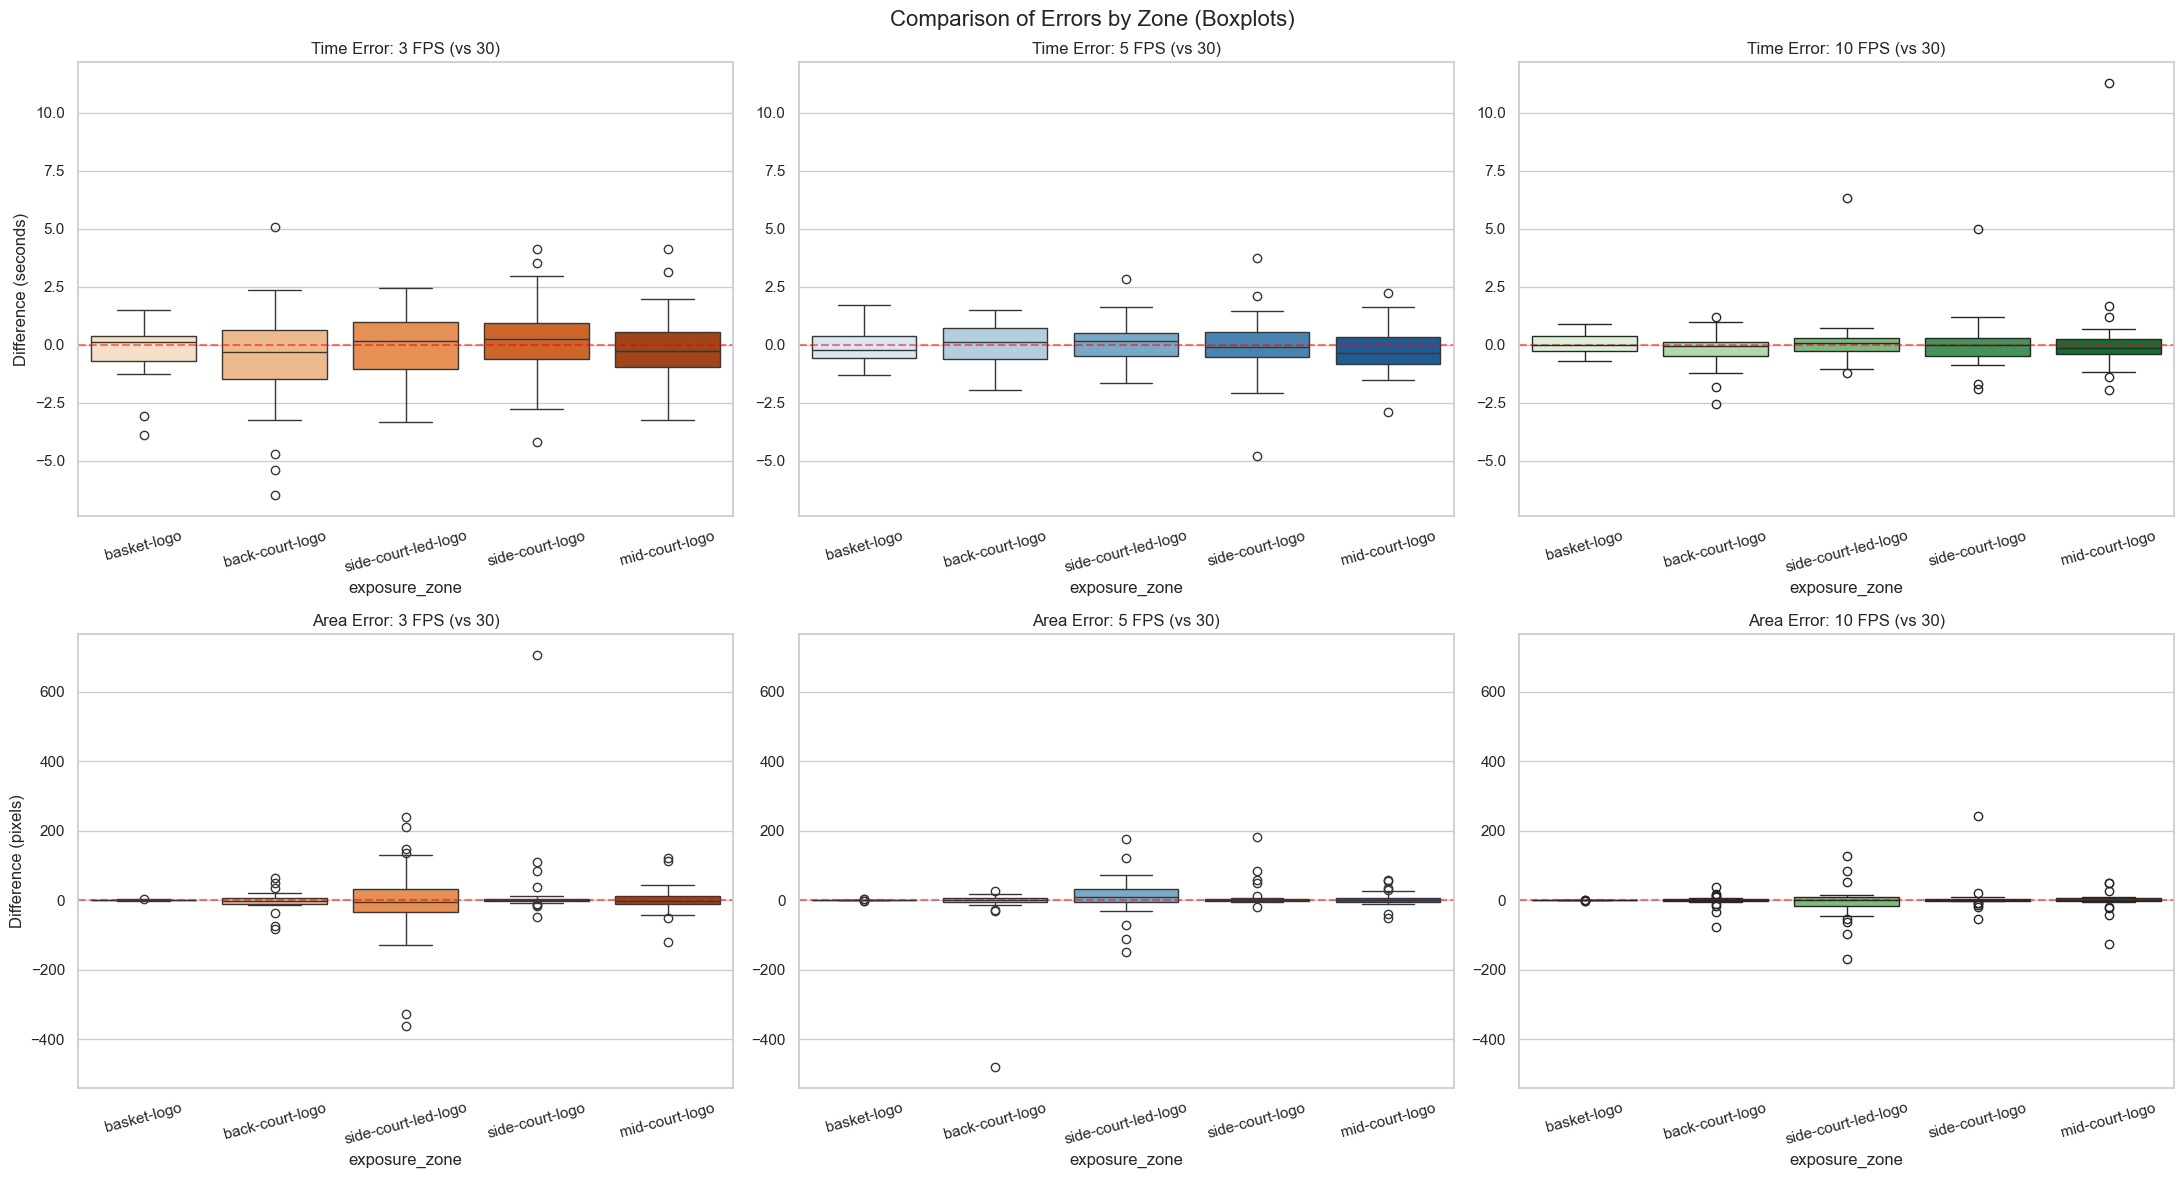

In [27]:
# 1. Calculation of common limits for the Y axis (to include 3, 5 and 10 FPS)
# Time
y_time_min = min(df_merge["exposure_time_diff_3_30"].min(), 
                 df_merge["exposure_time_diff_5_30"].min(), 
                 df_merge["exposure_time_diff_10_30"].min())

y_time_max = max(df_merge["exposure_time_diff_3_30"].max(), 
                 df_merge["exposure_time_diff_5_30"].max(), 
                 df_merge["exposure_time_diff_10_30"].max())

# 5% margin
y_time_lim = (y_time_min - (y_time_max-y_time_min)*0.05, y_time_max + (y_time_max-y_time_min)*0.05)

# Area
y_area_min = min(df_merge["average_box_area_diff_3_30"].min(), 
                 df_merge["average_box_area_diff_5_30"].min(), 
                 df_merge["average_box_area_diff_10_30"].min())

y_area_max = max(df_merge["average_box_area_diff_3_30"].max(), 
                 df_merge["average_box_area_diff_5_30"].max(), 
                 df_merge["average_box_area_diff_10_30"].max())

# 5% margin
y_area_lim = (y_area_min - (y_area_max-y_area_min)*0.05, y_area_max + (y_area_max-y_area_min)*0.05)


# 2. Creation of the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 12)) # Widened figure for 3 columns
fig.suptitle("Comparison of Errors by Zone (Boxplots)", fontsize=16)

# --- Row 1: Exposure time ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_3_30', ax=axes[0, 0], palette="Oranges")
axes[0, 0].set_title("Time Error: 3 FPS (vs 30)")
axes[0, 0].set_ylabel("Difference (seconds)")
axes[0, 0].set_ylim(y_time_lim)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_5_30', ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Time Error: 5 FPS (vs 30)")
axes[0, 1].set_ylabel("")
axes[0, 1].set_ylim(y_time_lim)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_10_30', ax=axes[0, 2], palette="Greens")
axes[0, 2].set_title("Time Error: 10 FPS (vs 30)")
axes[0, 2].set_ylabel("")
axes[0, 2].set_ylim(y_time_lim)
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].tick_params(axis='x', rotation=15)


# --- Row 2: Average Area ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_box_area_diff_3_30', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Area Error: 3 FPS (vs 30)")
axes[1, 0].set_ylabel("Difference (pixels)")
axes[1, 0].set_ylim(y_area_lim)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_box_area_diff_5_30', ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Area Error: 5 FPS (vs 30)")
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(y_area_lim)
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='average_box_area_diff_10_30', ax=axes[1, 2], palette="Greens")
axes[1, 2].set_title("Area Error: 10 FPS (vs 30)")
axes[1, 2].set_ylabel("")
axes[1, 2].set_ylim(y_area_lim)
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [28]:
# Calcul des pourcentages d'erreur (Erreur Relative)
# Formule : (Valeur_Approchée - Valeur_Réelle) / Valeur_Réelle * 100
# Résultat négatif = Sous-estimation | Résultat positif = Sur-estimation

# --- Calcul pour 3 FPS ---
df_merge['exposure_time_pct_error_3'] = (
    (df_merge['exposure_time_seconds_f3'] - df_merge['exposure_time_seconds_f30']) / df_merge['exposure_time_seconds_f30']
) * 100

df_merge['average_area_pct_error_3'] = (
    (df_merge['average_box_area_pixels_f3'] - df_merge['average_box_area_pixels_f30']) / df_merge['average_box_area_pixels_f30']
) * 100

# --- Calcul pour 5 FPS ---
df_merge['exposure_time_pct_error_5'] = (
    (df_merge['exposure_time_seconds_f5'] - df_merge['exposure_time_seconds_f30']) / df_merge['exposure_time_seconds_f30']
) * 100

df_merge['average_area_pct_error_5'] = (
    (df_merge['average_box_area_pixels_f5'] - df_merge['average_box_area_pixels_f30']) / df_merge['average_box_area_pixels_f30']
) * 100

# --- Calcul pour 10 FPS ---
df_merge['exposure_time_pct_error_10'] = (
    (df_merge['exposure_time_seconds_f10'] - df_merge['exposure_time_seconds_f30']) / df_merge['exposure_time_seconds_f30']
) * 100

df_merge['average_area_pct_error_10'] = (
    (df_merge['average_box_area_pixels_f10'] - df_merge['average_box_area_pixels_f30']) / df_merge['average_box_area_pixels_f30']
) * 100


# Affichage des statistiques descriptives des erreurs en pourcentage
print("--- Statistiques globales de l'erreur en pourcentage (3, 5 et 10 FPS) ---")
cols_to_describe = [
    'exposure_time_pct_error_3', 'average_area_pct_error_3', 
    'exposure_time_pct_error_5', 'average_area_pct_error_5',
    'exposure_time_pct_error_10', 'average_area_pct_error_10'
]
display(df_merge[cols_to_describe].describe())

print("\n--- Détail de l'erreur en pourcentage par zone : 3 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_pct_error_3', 
                                           'average_area_pct_error_3']].describe())

print("\n--- Détail de l'erreur en pourcentage par zone : 5 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_pct_error_5', 
                                           'average_area_pct_error_5']].describe())

print("\n--- Détail de l'erreur en pourcentage par zone : 10 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_pct_error_10', 
                                           'average_area_pct_error_10']].describe())

--- Statistiques globales de l'erreur en pourcentage (3, 5 et 10 FPS) ---


,exposure_time_pct_error_3,average_area_pct_error_3,exposure_time_pct_error_5,average_area_pct_error_5,exposure_time_pct_error_10,average_area_pct_error_10
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,-0.438060,-0.795974,-0.303675,-0.403970,-0.161824,0.026336
std,7.618752,6.664864,4.581586,3.104390,4.760840,2.526460
min,-50.746269,-69.025197,-40.298507,-23.954405,-47.368421,-23.788594
25%,-0.190091,-0.283502,-0.150509,-0.221278,-0.080919,-0.137521
50%,0.026307,0.002906,0.035630,-0.062787,0.007274,-0.007254
75%,0.250008,0.252454,0.179715,0.091577,0.100299,0.093297
max,34.817814,12.329237,21.457490,11.484509,29.554656,16.260928



--- Détail de l'erreur en pourcentage par zone : 3 FPS ---


exposure_time_pct_error_3                                  \
                                        count      mean        std        min   
exposure_zone                                                                   
back-court-logo                          30.0  0.972759   6.318731 -20.000000   
basket-logo                              30.0  0.048248   0.245925  -0.303218   
mid-court-logo                           30.0 -0.024404   1.670333  -7.869482   
side-court-led-logo                      30.0  0.024507   0.486474  -0.661917   
side-court-logo                          30.0 -3.211411  15.638443 -50.746269   

                                                              \
                          25%       50%       75%        max   
exposure_zone                                                  
back-court-logo     -0.131675  0.099609  0.515422  25.737705   
basket-logo         -0.080450 -0.025497  0.157770   0.843371   
mid-court-logo      -0.122745  0.080360  0.317698   2.255809   
side-court-led-logo -0.270138 -0.031264  0.242291   1.813034   
side-court-logo     -0.603905 -0.063551  0.213029  34.817814   

                    average_area_pct_error_3                                  \
                                       count      mean        std        min   
exposure_zone                                                                  
back-court-logo                         30.0  0.054677   1.466110  -4.325108   
basket-logo                             30.0 -0.063495   0.202112  -0.538317   
mid-court-logo                          30.0 -0.068756   1.280295  -3.887443   
side-court-led-logo                     30.0 -0.074098   4.011984 -10.055646   
side-court-logo                         30.0 -3.828200  14.014362 -69.025197   

                                                              
                          25%       50%       75%        max  
exposure_zone                                                 
back-court-logo     -0.178848  0.036356  0.508108   4.202419  
basket-logo         -0.196273 -0.021630  0.064907   0.300138  
mid-court-logo      -0.260370  0.080907  0.204476   3.536433  
side-court-led-logo -1.470978  0.179084  0.938684  12.329237  
side-court-logo     -0.232621 -0.053433  0.093835   6.207733


--- Détail de l'erreur en pourcentage par zone : 5 FPS ---


exposure_time_pct_error_5                                  \
                                        count      mean        std        min   
exposure_zone                                                                   
back-court-logo                          30.0 -0.083798   1.048734  -4.000000   
basket-logo                              30.0  0.002629   0.158841  -0.333660   
mid-court-logo                           30.0  0.060617   0.516192  -1.533384   
side-court-led-logo                      30.0 -0.054781   0.411960  -1.943281   
side-court-logo                          30.0 -1.443044  10.227284 -40.298507   

                                                              \
                          25%       50%       75%        max   
exposure_zone                                                  
back-court-logo     -0.187819 -0.043301  0.183157   1.953784   
basket-logo         -0.086120  0.043509  0.127928   0.296829   
mid-court-logo      -0.101687  0.087005  0.253208   1.298701   
side-court-led-logo -0.109851 -0.027390  0.125568   0.615234   
side-court-logo     -0.185615  0.047493  0.497029  21.457490   

                    average_area_pct_error_5                                 \
                                       count      mean       std        min   
exposure_zone                                                                 
back-court-logo                         30.0  0.482623  2.154351  -0.750540   
basket-logo                             30.0 -0.053148  0.211513  -0.571001   
mid-court-logo                          30.0 -0.077938  0.618197  -1.521651   
side-court-led-logo                     30.0 -0.264002  1.592338  -2.862950   
side-court-logo                         30.0 -2.107383  6.151375 -23.954405   

                                                              
                          25%       50%       75%        max  
exposure_zone                                                 
back-court-logo     -0.133896 -0.002811  0.151875  11.484509  
basket-logo         -0.159950 -0.055379  0.029096   0.594351  
mid-court-logo      -0.193095 -0.002336  0.145292   1.439217  
side-court-led-logo -0.720091 -0.318689  0.224811   4.633027  
side-court-logo     -0.203492 -0.060135  0.051708   2.810833


--- Détail de l'erreur en pourcentage par zone : 10 FPS ---


exposure_time_pct_error_10                       \
                                         count      mean        std   
exposure_zone                                                         
back-court-logo                           30.0  0.239837   1.269425   
basket-logo                               30.0 -0.004444   0.092614   
mid-court-logo                            30.0 -0.025453   1.376168   
side-court-led-logo                       30.0 -0.074722   0.429066   
side-court-logo                           30.0 -0.944337  10.578435   

                                                                         \
                           min       25%       50%       75%        max   
exposure_zone                                                             
back-court-logo      -2.604757 -0.024967  0.015549  0.140961   5.333333   
basket-logo          -0.203252 -0.077345  0.000000  0.061795   0.158499   
mid-court-logo       -6.368311 -0.070404  0.044381  0.132364   2.687140   
side-court-led-logo  -2.239602 -0.096342 -0.016168  0.073589   0.255840   
side-court-logo     -47.368421 -0.130306  0.006331  0.159423  29.554656   

                    average_area_pct_error_10                                 \
                                        count      mean       std        min   
exposure_zone                                                                  
back-court-logo                          30.0 -0.045405  0.659026  -2.104045   
basket-logo                              30.0  0.006356  0.137051  -0.257821   
mid-court-logo                           30.0  0.035167  0.844152  -1.579165   
side-court-led-logo                      30.0  0.231065  1.177341  -2.203526   
side-court-logo                          30.0 -0.095504  5.493546 -23.788594   

                                                              
                          25%       50%       75%        max  
exposure_zone                                                 
back-court-logo     -0.085495  0.000994  0.085952   1.877050  
basket-logo         -0.061985  0.001031  0.047659   0.457656  
mid-court-logo      -0.155712 -0.034106  0.088065   3.583851  
side-court-led-logo -0.221792 -0.006544  0.633792   4.068034  
side-court-logo     -0.118640 -0.003867  0.066952  16.260928

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\581121179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\581121179.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\581121179.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m

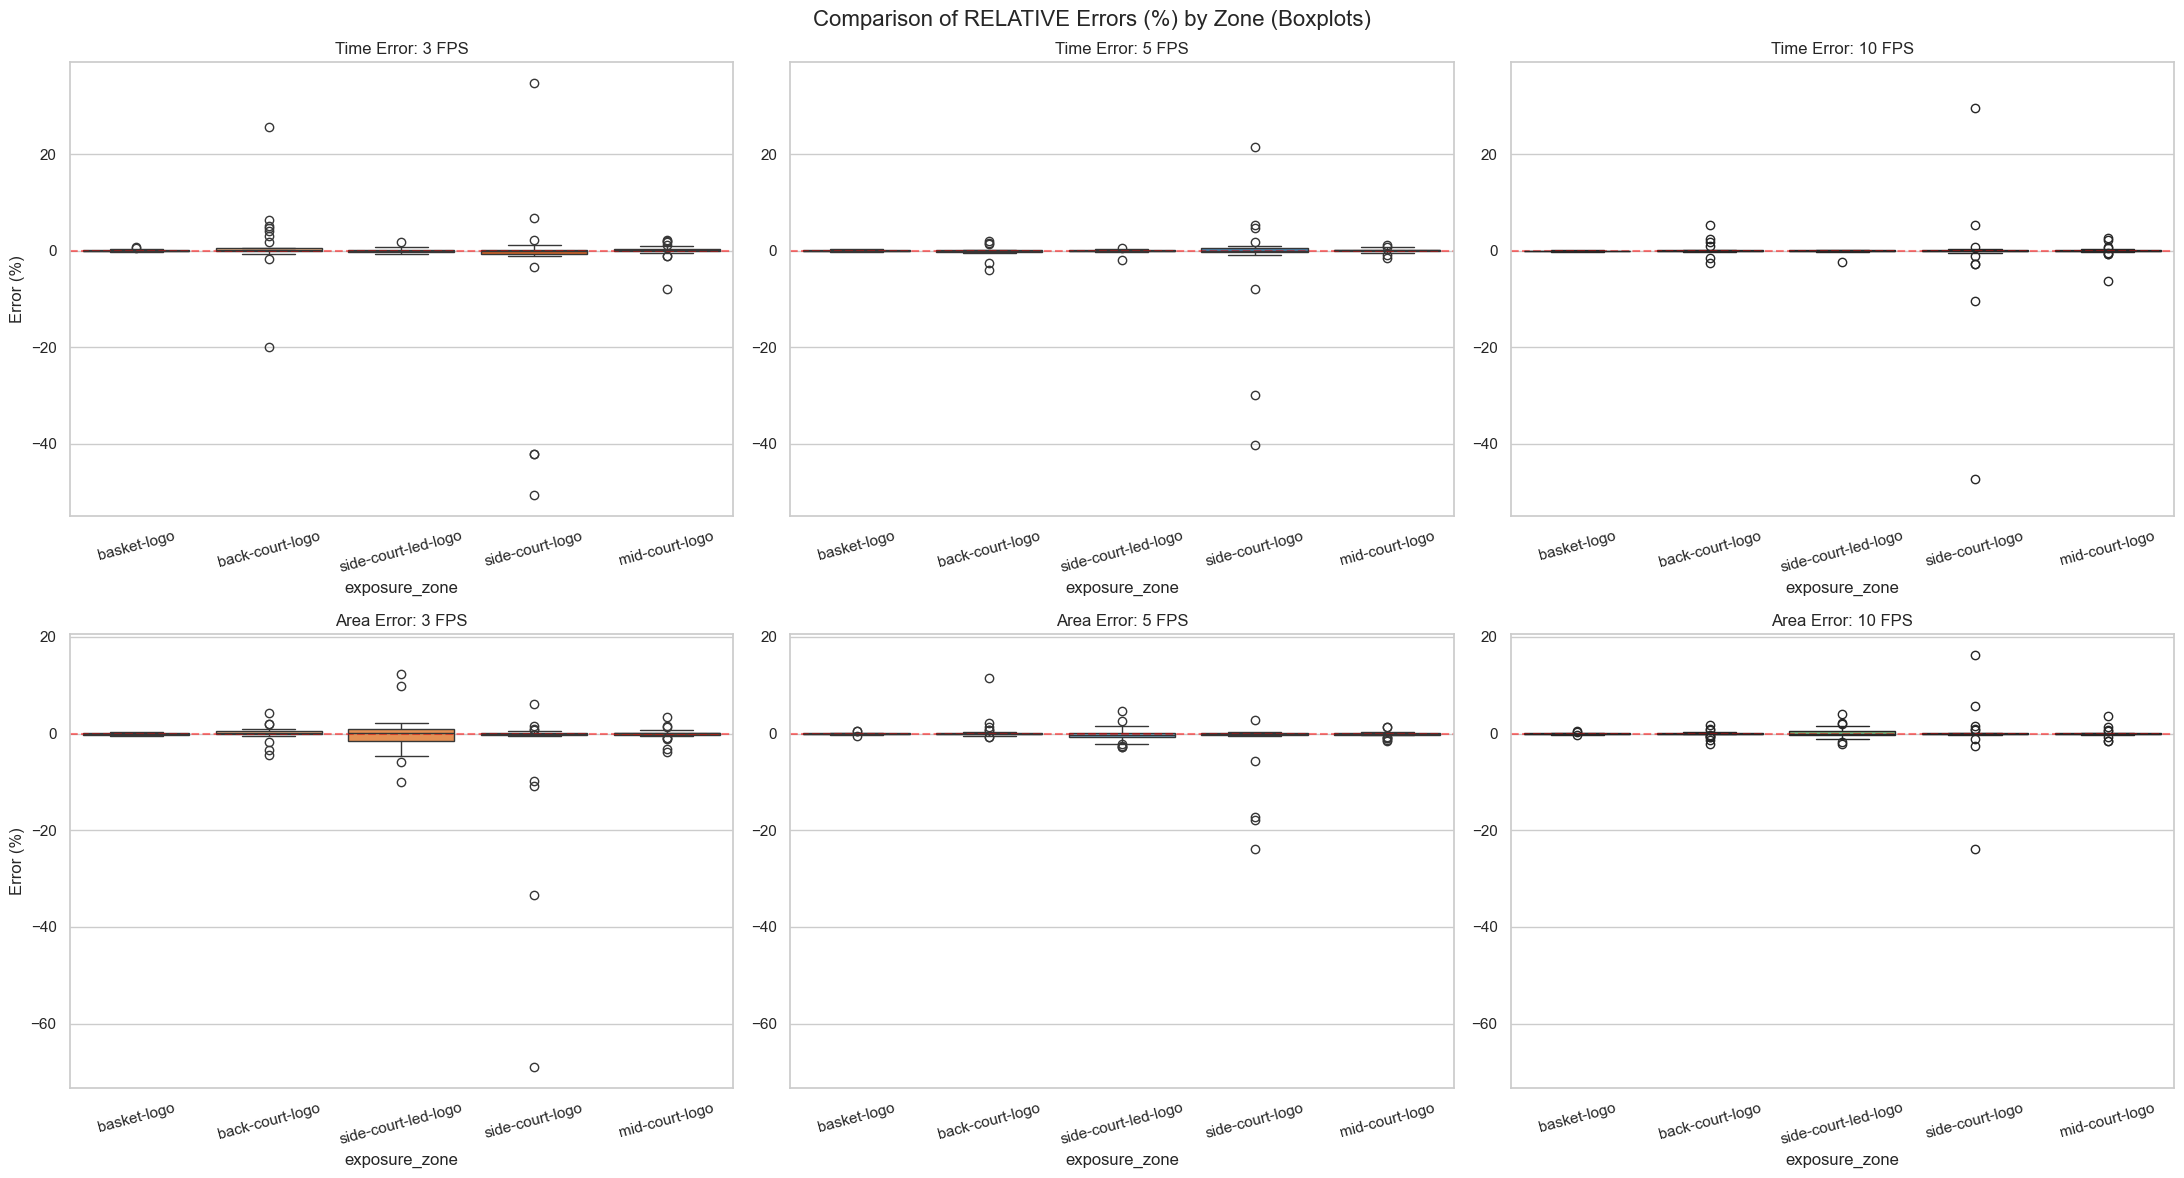

In [29]:
# 1. Calculation of common limits for the Y axis (including 3, 5 and 10 FPS)
# Time (%)
y_time_min = min(df_merge["exposure_time_pct_error_3"].min(), 
                 df_merge["exposure_time_pct_error_5"].min(), 
                 df_merge["exposure_time_pct_error_10"].min())

y_time_max = max(df_merge["exposure_time_pct_error_3"].max(), 
                 df_merge["exposure_time_pct_error_5"].max(), 
                 df_merge["exposure_time_pct_error_10"].max())

# 5% margin
y_time_lim = (y_time_min - (y_time_max-y_time_min)*0.05, y_time_max + (y_time_max-y_time_min)*0.05)

# Area (%)
y_area_min = min(df_merge["average_area_pct_error_3"].min(), 
                 df_merge["average_area_pct_error_5"].min(), 
                 df_merge["average_area_pct_error_10"].min())

y_area_max = max(df_merge["average_area_pct_error_3"].max(), 
                 df_merge["average_area_pct_error_5"].max(), 
                 df_merge["average_area_pct_error_10"].max())

# 5% margin
y_area_lim = (y_area_min - (y_area_max-y_area_min)*0.05, y_area_max + (y_area_max-y_area_min)*0.05)


# 2. Creation of the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Comparison of RELATIVE Errors (%) by Zone (Boxplots)", fontsize=16)

# --- Row 1: Exposure time (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
axes[0, 0].set_title("Time Error: 3 FPS")
axes[0, 0].set_ylabel("Error (%)")
axes[0, 0].set_ylim(y_time_lim) # Same scale
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Time Error: 5 FPS")
axes[0, 1].set_ylabel("") # We hide the label
axes[0, 1].set_ylim(y_time_lim) # Same scale
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_10', ax=axes[0, 2], palette="Greens")
axes[0, 2].set_title("Time Error: 10 FPS")
axes[0, 2].set_ylabel("")
axes[0, 2].set_ylim(y_time_lim) # Same scale
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].tick_params(axis='x', rotation=15)


# --- Row 2: Average Area (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_3', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Area Error: 3 FPS")
axes[1, 0].set_ylabel("Error (%)")
axes[1, 0].set_ylim(y_area_lim) # Same scale
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_5', ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Area Error: 5 FPS")
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(y_area_lim) # Same scale
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_10', ax=axes[1, 2], palette="Greens")
axes[1, 2].set_title("Area Error: 10 FPS")
axes[1, 2].set_ylabel("")
axes[1, 2].set_ylim(y_area_lim) # Same scale
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\564408171.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\564408171.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\564408171.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m

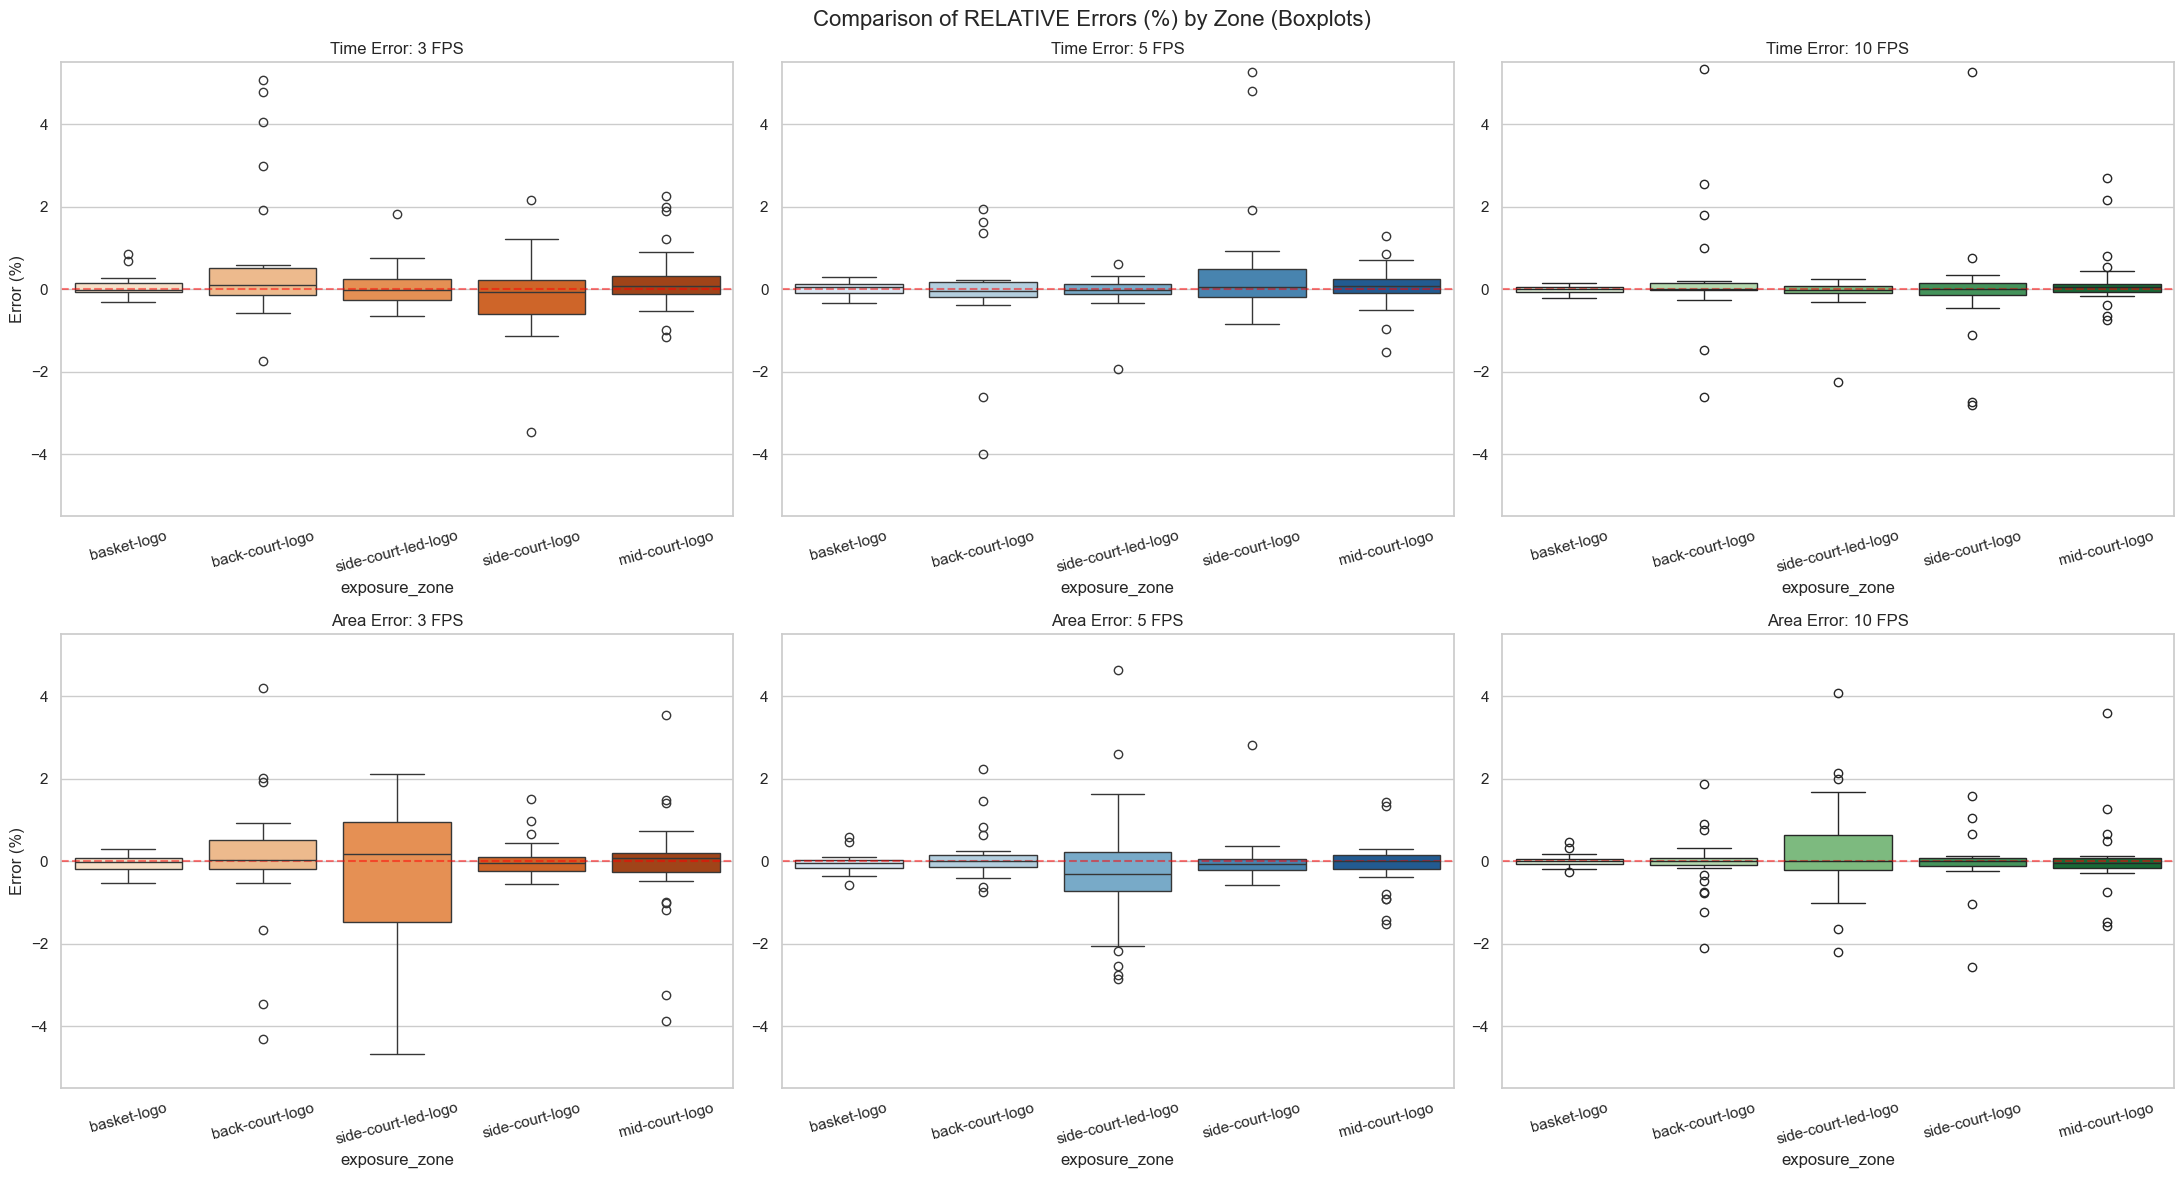

In [30]:
# 1. Calculation of common limits for the Y axis (including 3, 5 and 10 FPS)
# Time (%)
y_time_min = -5
y_time_max = 5

# 5% margin
y_time_lim = (y_time_min - (y_time_max-y_time_min)*0.05, y_time_max + (y_time_max-y_time_min)*0.05)

# Area (%)
y_area_min = -5
y_area_max = 5

# 5% margin
y_area_lim = (y_area_min - (y_area_max-y_area_min)*0.05, y_area_max + (y_area_max-y_area_min)*0.05)


# 2. Creation of the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Comparison of RELATIVE Errors (%) by Zone (Boxplots)", fontsize=16)

# --- Row 1: Exposure time (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
axes[0, 0].set_title("Time Error: 3 FPS")
axes[0, 0].set_ylabel("Error (%)")
axes[0, 0].set_ylim(y_time_lim) # Same scale
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Time Error: 5 FPS")
axes[0, 1].set_ylabel("") # We hide the label
axes[0, 1].set_ylim(y_time_lim) # Same scale
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_10', ax=axes[0, 2], palette="Greens")
axes[0, 2].set_title("Time Error: 10 FPS")
axes[0, 2].set_ylabel("")
axes[0, 2].set_ylim(y_time_lim) # Same scale
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].tick_params(axis='x', rotation=15)


# --- Row 2: Average Area (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_3', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Area Error: 3 FPS")
axes[1, 0].set_ylabel("Error (%)")
axes[1, 0].set_ylim(y_area_lim) # Same scale
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_5', ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Area Error: 5 FPS")
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(y_area_lim) # Same scale
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_10', ax=axes[1, 2], palette="Greens")
axes[1, 2].set_title("Area Error: 10 FPS")
axes[1, 2].set_ylabel("")
axes[1, 2].set_ylim(y_area_lim) # Same scale
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Conclusion

After analyzing all the data, we conclude that 5 FPS is the optimal choice for our production pipeline. When we look at the error distribution histograms, we can see that 5 FPS errors cluster tightly around zero, with most predictions off by less than 1 second. The 3 FPS distribution spreads much wider from -5 to +5 seconds, while the 10 FPS distribution looks almost identical to 5 FPS. This similarity between 5 FPS and 10 FPS is the key insight: if they have nearly the same accuracy, why pay double the processing cost for 10 FPS?

The boxplots by zone confirm that 5 FPS performs consistently well across all exposure zones. The error boxes are small and tight, with few outliers compared to 3 FPS. Even challenging zones like basket-logo and side-court-led-logo show reliable performance. The 10 FPS boxes are slightly smaller, but the difference is minimal and doesn't justify the extra computational cost. When we examine the percentage errors, we find that 5 FPS maintains a mean error of just -0.30% for exposure time and -0.40% for box area, compared to -0.16% and 0.03% for 10 FPS. This 0.2% difference is negligible for our business needs.

We decided against 10 FPS because it only provides 3x speedup while requiring twice as many frames as 5 FPS, yet delivers nearly identical accuracy. The standard deviation for exposure time is 4.58% at 5 FPS versus 4.76% at 10 FPS, which is essentially the same. We also decided against 3 FPS despite its attractive 10x speedup because the error distribution is too wide and unpredictable. The standard deviation jumps to 7.62% for time, and some videos show errors reaching 35%. While 3 FPS might work for aggregate statistics across many videos, it's too unreliable for individual video reporting, which is critical when clients ask about specific games.
With 5 FPS, we achieve a 6x speedup over ground truth, maintain under 1% average error, ensure reliable performance across all zones, and minimize outliers. This represents the best balance between processing speed and measurement accuracy for our production needs. We can confidently deploy this frame rate knowing that 95% of our measurements will be highly accurate, while the remaining 5% can be flagged for review if needed.